In [22]:
from weylchamber import WeylChamber
from numpy import kron
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import FloatSlider, interact
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis.two_qubit import TwoQubitWeylDecomposition
from qiskit.visualization import plot_bloch_vector
from qiskit.visualization.state_visualization import _bloch_multivector_data
from qutip import Qobj, sigmax, sigmay, sigmaz, tensor
from scipy.linalg import expm
from weylchamber import c1c2c3
from can_sandwich.bgate import BGate
from tqdm.notebook import tqdm
from qutip import qeye
from qutip.qip.operations import rx, rz

In [23]:
def canonicalize_circuit(current_gate):
    return TwoQubitWeylDecomposition(current_gate, fidelity=1.0).circuit(
        euler_basis="U3"
    )


def zx_canonical_circuit(current_gate):
    return TwoQubitWeylDecomposition(current_gate, fidelity=1.0).circuit(
        euler_basis="ZXZ"
    )


def canonicalize(current_gate):
    return Operator(canonicalize_circuit(current_gate)).data


SxSx = tensor(sigmax(), sigmax()).full()
SySy = tensor(sigmay(), sigmay()).full()
SzSz = tensor(sigmaz(), sigmaz()).full()


def canonical_gate(a, b, c):
    return expm(np.array(1j * (a * SxSx + b * SySy + c * SzSz)))

In [24]:
x = np.pi / 8
b, c = np.pi / 4, np.pi / 4
sq = Qobj((-1j * tensor(qeye(2), x * sigmax())).expm(), dims=[4, 4])
u = Qobj(canonical_gate(0.46, b, c)).dag() @ sq @ Qobj(canonical_gate(0.46, b, c))

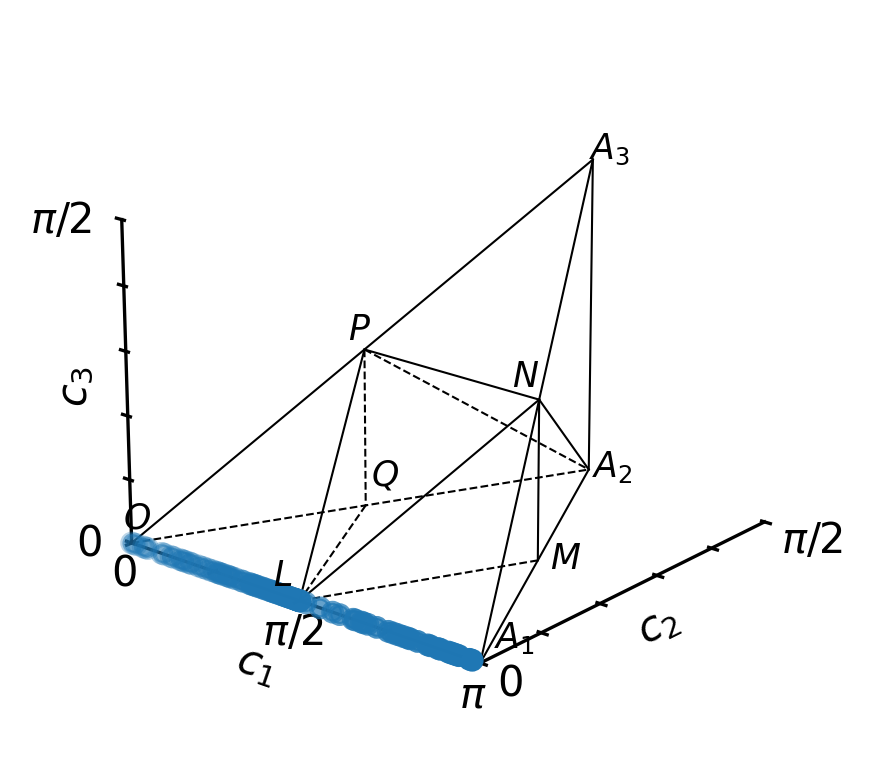

In [25]:
w = WeylChamber()
xarg = np.pi / 8  # ?
coords = []
for phi in np.linspace(0, np.pi, 100):
    single_q = Qobj(tensor(rz(phi), qeye(2)), dims=[[4], [4]])
    u = (
        Qobj(canonical_gate(xarg, 0.0, 0)).dag()
        @ single_q
        @ Qobj(canonical_gate(xarg, 0, 0))
    )
    c = c1c2c3(u)
    coords.append(c)

w.scatter(*zip(*coords))
w.plot()

  0%|          | 0/50 [00:00<?, ?it/s]

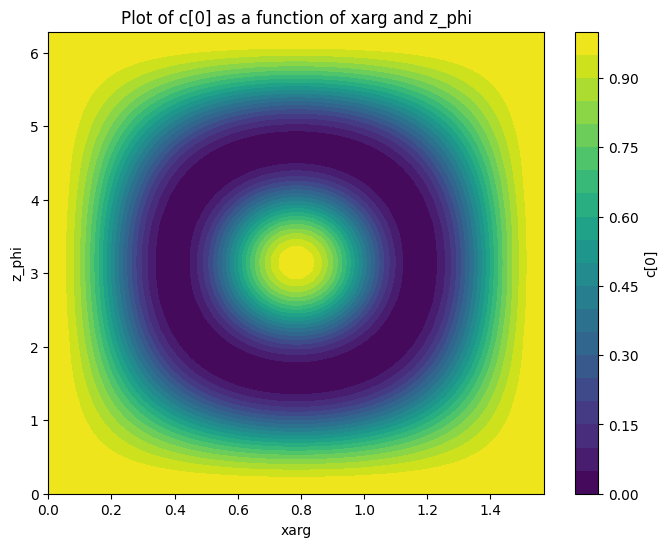

In [32]:
from weylchamber import g1g2g3
from tqdm.notebook import tqdm

xarg_values = np.linspace(0, np.pi / 2, 50)  # Range of xarg values
z_phi_values = np.linspace(0, 2 * np.pi, 100)  # Range of z_phi values
coords = []

for xarg in tqdm(xarg_values):
    for phi in z_phi_values:
        single_q = Qobj(tensor(rz(phi), qeye(2)), dims=[[4], [4]])
        u = (
            Qobj(canonical_gate(xarg, 0.0, 0)).dag()
            @ single_q
            @ Qobj(canonical_gate(xarg, 0, 0))
        )
        # c = list(c1c2c3(u))
        # if c[0] > 0.5:
        #     c[0] = 1 - c[0]
        c = list(g1g2g3(u))
        g_xarg = g1g2g3(Qobj(canonical_gate(xarg, 0, 0)))[1]
        coords.append([g_xarg, phi, c[0]])  # Store xarg, phi, and c[0]

# Convert to a NumPy array for easier handling
coords = np.array(coords)

# Reshape the c[0] values (Z) to match the grid shape
Z = coords[:, 2].reshape(len(xarg_values), len(z_phi_values)).T

# Create the meshgrid for xarg (X) and z_phi (Y)
X, Y = np.meshgrid(xarg_values, z_phi_values)

# Create the plot
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, 20, cmap="viridis")
plt.colorbar(label="c[0]")
plt.xlabel("xarg")
plt.ylabel("z_phi")
plt.title("Plot of c[0] as a function of xarg and z_phi")
plt.show()

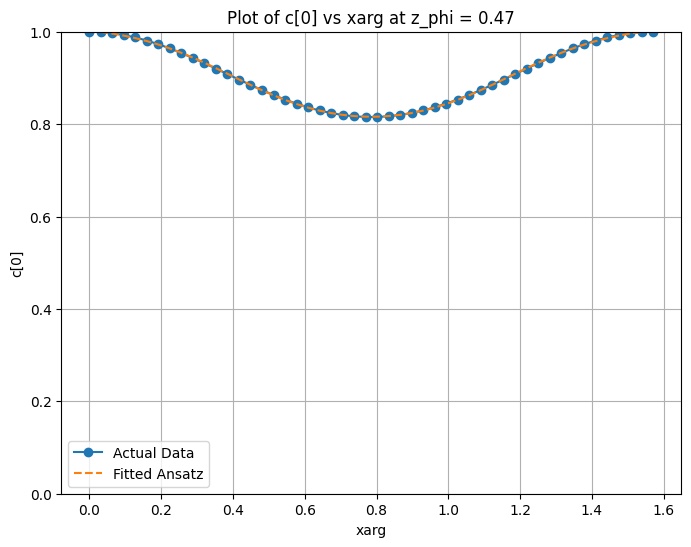

Optimized Parameters: A1=-0.131, A2=-0.131, alpha1=7.722, alpha2=7.722, x1=0.591, x2=0.979, offset=1.012


In [27]:
from scipy.optimize import curve_fit


# Define a refined double well potential ansatz
def refined_double_well_ansatz(x, A1, A2, alpha1, alpha2, x1, x2, offset):
    return (
        A1 * np.exp(-alpha1 * (x - x1) ** 2) + A2 * np.exp(-alpha2 * (x - x2) ** 2)
    ) + offset


# Find closest index to z_phi_slice
z_phi_slice = np.pi / 2 * 0.3
z_phi_index = np.argmin(np.abs(z_phi_values - z_phi_slice))
c0_slice = Z[z_phi_index, :]  # Get the slice of c[0] values for the selected z_phi

# Initial guesses for the parameters [A1, A2, alpha1, alpha2, x1, x2, offset]
initial_guess = [0.5, 0.5, 10, 10, 0.5, 1.1, 0]  # Adjust these based on what you see

# Fit the refined double well ansatz to the data
popt, pcov = curve_fit(
    refined_double_well_ansatz, xarg_values, c0_slice, p0=initial_guess, maxfev=10000
)

# Generate the fitted curve using the optimized parameters
fitted_curve = refined_double_well_ansatz(xarg_values, *popt)

# Plot the actual data and the fitted curve
plt.figure(figsize=(8, 6))
plt.plot(xarg_values, c0_slice, marker="o", label="Actual Data")
plt.plot(xarg_values, fitted_curve, label="Fitted Ansatz", linestyle="--")
plt.xlabel("xarg")
plt.ylabel("c[0]")
plt.title(f"Plot of c[0] vs xarg at z_phi = {z_phi_slice:.2f}")
plt.ylim(0, 1)  # Set fixed y-axis limits
plt.grid(True)
plt.legend()
plt.show()

# Output the optimized parameters for the fitted ansatz
print(
    f"Optimized Parameters: A1={popt[0]:.3f}, A2={popt[1]:.3f}, alpha1={popt[2]:.3f}, alpha2={popt[3]:.3f}, x1={popt[4]:.3f}, x2={popt[5]:.3f}, offset={popt[6]:.3f}"
)

In [28]:
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image
# from io import BytesIO

# # List to store frames for the GIF
# frames = []

# # Set a fixed y-axis range based on the expected range of c[0]
# y_min, y_max = 0, 1  # Adjust this range based on the data

# # Define the range of z_phi values for the GIF
# z_phi_range = np.linspace(0, 2 * np.pi, 100)

# # Generate frames for each value of z_phi
# for z_phi_slice in z_phi_range:
#     # Find closest index to z_phi_slice
#     z_phi_index = np.argmin(np.abs(z_phi_values - z_phi_slice))
#     c0_slice = Z[z_phi_index, :]  # Get the slice of c[0] values for the selected z_phi

#     # Plot c[0] vs xarg for the selected z_phi_slice
#     plt.figure(figsize=(8, 6))
#     plt.plot(xarg_values, c0_slice, marker="o")
#     plt.xlabel("xarg")
#     plt.ylabel("c[0]")
#     plt.title(f"Plot of c[0] vs xarg at z_phi = {z_phi_slice:.2f}")
#     plt.ylim(y_min, y_max)  # Set fixed y-axis limits
#     plt.grid(True)

#     # Save the figure to a buffer instead of saving to a file
#     buf = BytesIO()
#     plt.savefig(buf, format="png")
#     buf.seek(0)
#     img = Image.open(buf)
#     frames.append(img.copy())  # Append image to frames
#     buf.close()
#     plt.close()

# # Save all frames as a GIF
# frames[0].save(
#     "c0_vs_xarg_animation.gif",
#     save_all=True,
#     append_images=frames[1:],  # Append remaining frames
#     duration=100,  # Duration per frame (100 ms)
#     loop=0,  # Infinite loop
# )

# print("GIF saved as c0_vs_xarg_animation.gif")

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Define the radially symmetric double well ansatz with axis scaling
def radially_symmetric_ansatz(X, A1, A2, alpha1, alpha2, r0, offset):
    xarg = X[0]
    z_phi = X[1]

    # Radial distance with z_phi stretched by a factor of 4 (since z_phi spans 0 to 2pi)
    r = np.sqrt((xarg - np.pi / 4) ** 2 + (z_phi - np.pi) ** 2 / 4)

    # Double well behavior in terms of the radial distance
    well1 = A1 * np.exp(-alpha1 * (r - r0) ** 2)  # Center well
    well2 = A2 * np.exp(-alpha2 * (r + r0) ** 2)  # Side well

    return well1 + well2 + offset


# Flatten the meshgrid coordinates for fitting
xarg_flat = X.ravel()
z_phi_flat = Y.ravel()
coords_flat = np.array([xarg_flat, z_phi_flat])

# Initial guesses for the parameters [A1, A2, alpha1, alpha2, r0, offset]
initial_guess = [0.5, 0.5, 10, 10, 0.5, 0]

# Fit the radially symmetric ansatz to the actual data
popt, pcov = curve_fit(
    radially_symmetric_ansatz, coords_flat, Z.ravel(), p0=initial_guess
)

# Generate the fitted ansatz using the optimal parameters
Z_ansatz = radially_symmetric_ansatz(coords_flat, *popt).reshape(Z.shape)

# Plotting the actual data, the fitted ansatz, and the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the actual data
axs[0].contourf(X, Y, Z, 20, cmap="viridis")
axs[0].set_title("Actual Data")
axs[0].set_xlabel("xarg")
axs[0].set_ylabel("z_phi")

# Plot the fitted ansatz
axs[1].contourf(X, Y, Z_ansatz, 20, cmap="viridis")
axs[1].set_title("Fitted Ansatz")
axs[1].set_xlabel("xarg")
axs[1].set_ylabel("z_phi")

# Plot the residuals (difference between actual data and the ansatz)
residuals = Z - Z_ansatz
axs[2].contourf(X, Y, residuals, 20, cmap="coolwarm")
axs[2].set_title("Residuals")
axs[2].set_xlabel("xarg")
axs[2].set_ylabel("z_phi")

plt.tight_layout()
plt.show()

# Print out the fitted parameters
print(f"Fitted parameters: {popt}")

/tmp/ipykernel_5265/844940435.py:16: RuntimeWarning: overflow encountered in exp
  well2 = A2 * np.exp(-alpha2 * (r + r0) ** 2)  # Side well
/tmp/ipykernel_5265/844940435.py:16: RuntimeWarning: overflow encountered in multiply
  well2 = A2 * np.exp(-alpha2 * (r + r0) ** 2)  # Side well


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.